# Imagix3D
## Results check

Here, we are going to check out the results of Imagix3D pipeline runs on the HPC cluster

**Setting the Correct Path**

In [2]:
import os

p = os.getcwd()
d = "autoencodix_package"
if d not in p:
    raise FileNotFoundError(f"'{d}' not found in path: {p}")
os.chdir(os.sep.join(p.split(os.sep)[: p.split(os.sep).index(d) + 1]))
print(f"Changed to: {os.getcwd()}")

Changed to: C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package


### Loading the data
**Please Note:** The following approach for loading an Imagix3D pipeline object is only necessary if the pipeline ran on a **GPU** machine (i.e. *HPC Alpha*) with a **Unix** OS, and you want to <ins>investigate the results on a Windows PC</ins>. It uses a PyTorch patch to work around a CUDA deserialization problem that occurs on Windows machines. <ins>However:</ins> loading like this also seems to work for results from a CPU cluster.

In [1]:
import os
import io
import signal
import torch
import autoencodix as acx

# Define path of the to-be-loaded results object
basepath = r"C:/chris/FU/Msc_Data_Science/Masterarbeit/hpc_pipelines/results"
results_folder = "gpu_synapse_64cube_250epochs_2026-06-12_19-55-27"
outpath = os.path.join(basepath, results_folder, "imagix3d.pkl")

# Compatibility fix for Linux-created pickle files.
# Windows does not define signal.SIGUSR1, but the pickle expects it.
if not hasattr(signal, "SIGUSR1"):
    signal.SIGUSR1 = 1 # the assigned value is arbitrary

# Save PyTorch's original internal tensor-storage loader.
_original_load_from_bytes = torch.storage._load_from_bytes

# Define a replacement loader that maps CUDA tensors to CPU.
def _load_from_bytes_cpu(b):
    return torch.load(io.BytesIO(b), map_location=torch.device("cpu"))

# Temporarily replace PyTorch's loader.
torch.storage._load_from_bytes = _load_from_bytes_cpu

try:
    imagix3d_loaded = acx.Imagix3D.load(outpath)
finally:
    # Restore PyTorch's original behavior.
    torch.storage._load_from_bytes = _original_load_from_bytes

Attempting to load a pipeline from C:/chris/FU/Msc_Data_Science/Masterarbeit/hpc_pipelines/results/gpu_synapse_64cube_250epochs_2026-06-12_19-55-27\imagix3d.pkl...
Pipeline object loaded successfully. Actual type: Imagix3D
Preprocessor loaded successfully.


### Print VAE Model Output

In [3]:
display(imagix3d_loaded.result.model)

VolumeVAEArchitecture(
  (_encoder): Sequential(
    (0): Conv3d(1, 16, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv3d(16, 32, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (3): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv3d(32, 64, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (6): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv3d(64, 128, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (9): BatchNorm3d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2)
    (11): Conv3d(128, 128, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
    (12): BatchNorm3d(128, eps=1e-05, momen

### Print Overview of Config Settings

In [4]:
import json
import pandas as pd
from IPython.display import display
from enum import Enum
from pathlib import Path

def make_json_safe(obj):
    """Recursively convert objects into JSON-friendly Python objects."""
    if isinstance(obj, Enum):
        return obj.value
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_safe(v) for v in obj]
    return obj

def config_to_dict(config):
    """Convert Pydantic config object to a plain dictionary."""
    if hasattr(config, "model_dump"):  # Pydantic v2
        cfg = config.model_dump(mode="python")
    elif hasattr(config, "dict"):      # Pydantic v1
        cfg = config.dict()
    else:
        raise TypeError(f"Unsupported config type: {type(config)}")

    return make_json_safe(cfg)

cfg = config_to_dict(imagix3d_loaded.config)

print(json.dumps(cfg, indent=2, ensure_ascii=False))

{
  "data_config": {
    "data_info": {
      "IMG": {
        "file_path": "/data/horse/ws/baeuchl-imagix3d/data/medmnist/synapse3d/test",
        "data_type": "IMG",
        "scaling": "MINMAX",
        "filtering": "VAR",
        "sep": null,
        "extra_anno_file": null,
        "is_single_cell": false,
        "min_cells": 0.05,
        "min_genes": 0.02,
        "selected_layers": [
          "X"
        ],
        "is_X": false,
        "normalize_counts": true,
        "log_transform": false,
        "k_filter": null,
        "img_width_resize": 64,
        "img_height_resize": 64,
        "translate_direction": null,
        "pretrain_epochs": null
      },
      "ANNO": {
        "file_path": "/data/horse/ws/baeuchl-imagix3d/data/medmnist/synapse3d/test_metadata.csv",
        "data_type": "ANNOTATION",
        "scaling": "NOTSET",
        "filtering": "VAR",
        "sep": null,
        "extra_anno_file": null,
        "is_single_cell": false,
        "min_cells": 0.05,
  

### The Evaluate Step

Here, we use the `latent space` and compare it to other dimensionality reduction techniques like PCA, UMAP, or a random baseline.  
In the basic case, you can specify a column in your annotation data to use for a machine learning task, e.g., training a classifier on disease state or cancer type. We then use the representations (latent space, UMAP, etc.) to train this classifier/regressor.  
You have many options to customize this step for your needs, such as passing a scikit-learn model and defining evaluation metrics. Please refer to [3] for a complete guide.

[3] Tutorials/DeepDives/EvaluateTutorial.ipynb

Perform ML task with feature df: PCA
PCA
Perform ML task for target parameter: group
Perform ML task with feature df: UMAP
UMAP
Perform ML task for target parameter: group
Perform ML task with feature df: RandomFeature
RandomFeature_R1
Perform ML task for target parameter: group
RandomFeature_R2
Perform ML task for target parameter: group
RandomFeature_R3
Perform ML task for target parameter: group
RandomFeature_R4
Perform ML task for target parameter: group
RandomFeature_R5
Perform ML task for target parameter: group
Perform ML task with feature df: Latent
Latent
Perform ML task for target parameter: group
CPU times: total: 5min 7s
Wall time: 4min 33s


Result Object Public Attributes:
------------------------------
latentspaces: TrainingDynamics object
sample_ids: TrainingDynamics object
reconstructions: TrainingDynamics object
mus: TrainingDynamics object
sigmas: TrainingDynamics object
losses: TrainingDynamics object
sub_losses: LossRegistry(_losses={'recon_loss': TrainingDynamics(), 'var_loss': TrainingDynamics(), 'anneal_factor': TrainingDynamics(), 'effective_beta_factor': TrainingDynamics()})
preprocessed_data: Tensor of shape (0,)
model: VolumeVAEArchitecture
model_checkpoints: TrainingDynamics object
datasets: DatasetContainer(train=<autoencodix.data._image_dataset.ImageDataset object at 0x00000219DF39E510>, valid=<autoencodix.data._image_dataset.ImageDataset object at 0x00000219EF929D50>, test=<autoencodix.data._image_dataset.ImageDataset object at 0x00000219DF2EEF10>)
new_datasets: DatasetContainer(train=None, valid=None, test=None)
adata_latent: AnnData object with n_obs × n_vars = 71 × 32
    uns: 'var_names'
final_recons

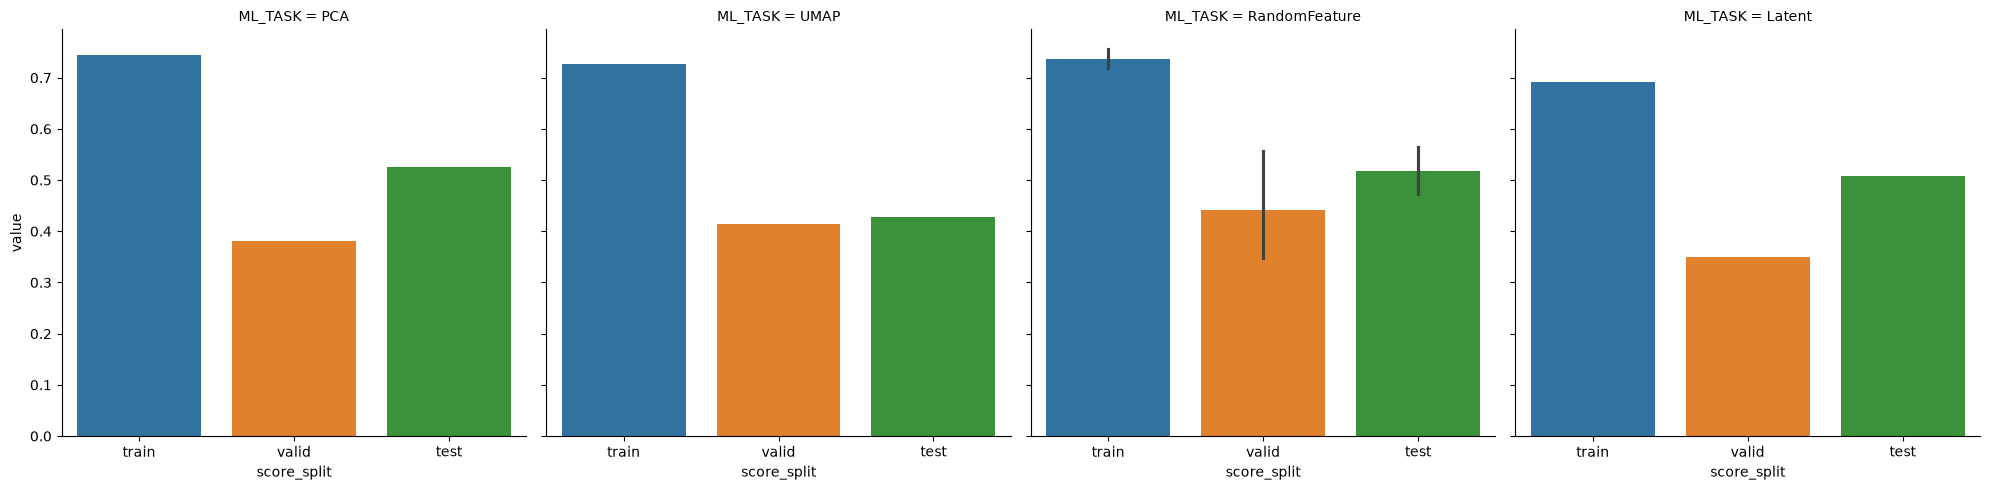

In [5]:
%%time
# In our annotation file, we have a column called "group"
# that refers to the age group of our subjects.
imagix3d_loaded.evaluate(
    params=["group"],
    reference_methods=["PCA", "UMAP", "RandomFeature"]  #TSNE
)

## IF RandomFeature does not converge, use this variant:
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression

# clf = make_pipeline(
#     StandardScaler(),
#     LogisticRegression(max_iter=2000)
# )

# imagix3d_loaded.evaluate(
#     params=["group"],
#     reference_methods=["PCA", "UMAP", "RandomFeature"],
#     ml_model_class=clf
# )

In [ ]:
# Next, we can visualize the evaluation output with:
import matplotlib.pyplot as plt
plt.close("all")
imagix3d_loaded.visualizer.show_evaluation(
    param="group",
    metric="roc_auc_ovo",
)

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import pandas as pd

latent_df = imagix3d_loaded.result.get_latent_df(epoch=-1, split="test")

print(latent_df.shape)
display(latent_df.head())

n_samples = latent_df.shape[0]
perplexity = min(30, max(2, (n_samples - 1) // 3))

X = StandardScaler().fit_transform(latent_df)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=1,
    init="pca",
    learning_rate="auto"
)

tsne_arr = tsne.fit_transform(X)

tsne_df = pd.DataFrame(
    tsne_arr,
    index=latent_df.index,
    columns=["TSNE1", "TSNE2"]
)

display(tsne_df.head())

In [ ]:
meta = imagix3d_loaded._datasets.test.metadata

plot_df = tsne_df.join(meta[["group"]], how="left")

display(plot_df.head())

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

for group, sub in plot_df.groupby("group"):
    ax.scatter(sub["TSNE1"], sub["TSNE2"], label=group, alpha=0.8)

ax.set_xlabel("TSNE1")
ax.set_ylabel("TSNE2")
ax.legend(title="group")
plt.show()

In [ ]:
n_samples = latent_df.shape[0]

# t-SNE perplexity must be smaller than the number of samples.
perplexity = min(30, max(2, (n_samples - 1) // 3))

X = StandardScaler().fit_transform(latent_df)

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=1,
    init="pca",
    learning_rate="auto"
)

tsne_arr = tsne.fit_transform(X)

tsne_df = pd.DataFrame(
    tsne_arr,
    index=latent_df.index,
    columns=["TSNE1", "TSNE2"]
)

display(tsne_df.head())

In [6]:
display(imagix3d_loaded.result.embedding_evaluation)

,score_split,CLINIC_PARAM,metric,value,ML_ALG,ML_TYPE,ML_TASK,ML_SUBTASK
0,train,group,roc_auc_ovo,0.743939,LogisticRegression,classification,PCA,PCA
1,valid,group,roc_auc_ovo,0.380342,LogisticRegression,classification,PCA,PCA
2,test,group,roc_auc_ovo,0.525490,LogisticRegression,classification,PCA,PCA
0,train,group,roc_auc_ovo,0.727609,LogisticRegression,classification,UMAP,UMAP
1,valid,group,roc_auc_ovo,0.414530,LogisticRegression,classification,UMAP,UMAP
2,test,group,roc_auc_ovo,0.428431,LogisticRegression,classification,UMAP,UMAP
0,train,group,roc_auc_ovo,0.757323,LogisticRegression,classification,RandomFeature,RandomFeature_R1
1,valid,group,roc_auc_ovo,0.448718,LogisticRegression,classification,RandomFeature,RandomFeature_R1
2,test,group,roc_auc_ovo,0.455882,LogisticRegression,classification,RandomFeature,RandomFeature_R1
0,train,group,roc_auc_ovo,0.745118,LogisticRegression,classification,RandomFeature,RandomFeature_R2


In [7]:
from IPython.display import display

result = imagix3d_loaded.result
# Get the reconstructions of the test split
rec_test = result.reconstructions.get(split="test")

# Get sample_ids for this latent space
sample_ids = result.sample_ids.get(split="test")

# A utility wrapper to get the latent space as a DataFrame
display(result.get_latent_df(epoch=-1, split="test"))
display(result.mus.get(split="test", epoch=-1))
display(result.sigmas.get(split="test", epoch=-1))
display(result.sub_losses.get(key="var_loss"))

,LatDim_0,LatDim_1,LatDim_2,LatDim_3,LatDim_4,LatDim_5,LatDim_6,LatDim_7,LatDim_8,LatDim_9,...,LatDim_22,LatDim_23,LatDim_24,LatDim_25,LatDim_26,LatDim_27,LatDim_28,LatDim_29,LatDim_30,LatDim_31
test_00206,2.186350,1.215404,1.792265,-1.333038,2.470891,-0.479959,1.931168,2.858292,-0.784620,1.918766,...,-0.377609,0.365123,1.720281,-0.212934,-0.242494,-0.009440,0.328202,-1.810951,0.627744,0.177192
test_00207,0.772093,-0.704661,1.607803,-0.625910,1.687207,1.330149,0.733683,0.956556,-1.715886,-0.226380,...,3.982954,3.013494,1.941058,1.001373,-0.696049,-0.233017,-0.899340,1.102342,-0.144864,1.030717
test_00323,3.714643,2.197502,0.030153,1.644530,3.557558,-0.073836,1.755918,0.603943,-0.204722,3.391621,...,-0.953706,4.802831,0.343817,-0.428316,2.622114,-1.491145,3.044681,-0.070651,0.575310,2.262222
test_00176,-0.196429,7.842852,1.517246,-1.994958,2.973798,1.139242,2.458306,1.508296,1.468772,4.511684,...,1.512381,3.601449,0.052395,0.416126,0.677385,2.141845,0.433402,0.684179,-0.145138,0.033743
test_00290,0.345471,-1.311458,2.197523,1.680508,4.366664,-0.190226,-1.720241,2.439647,-0.630767,1.072462,...,1.779988,4.009875,1.846063,-0.452383,-0.519033,1.228486,2.457122,0.126935,1.449194,1.204904
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
test_00007,-2.569875,1.580675,-1.244908,-1.175501,2.828931,-0.504532,0.811212,1.946869,4.347683,2.067935,...,-1.228957,-0.380292,-0.175234,1.546377,-0.163184,-0.707646,3.216577,1.967521,0.860206,0.858833
test_00087,0.064859,0.415151,1.130686,-0.524755,2.474861,1.414010,1.258897,2.435836,2.967316,-0.914450,...,-2.569791,-0.045436,0.695097,2.601619,-0.295494,-0.731195,-0.553811,0.933557,1.182919,1.228081
test_00107,-2.084975,0.165059,2.393085,2.786354,0.884739,0.586092,0.672924,-0.215037,-0.413940,3.224459,...,0.421540,4.925863,1.707877,0.456343,0.371512,0.841801,0.568706,3.442837,3.520596,-0.602621
test_00164,0.371614,0.675425,0.691364,-0.244584,0.024318,1.554306,-0.033422,1.467079,0.859758,2.189042,...,0.485769,0.594919,0.309946,0.322936,2.333136,-0.344694,-0.143270,2.237686,1.063623,-1.987141


array([[0.7699166 , 2.898533  , 0.        , ..., 0.        , 1.6569339 ,
        0.        ],
       [0.22686262, 1.0582591 , 1.8243849 , ..., 0.        , 0.14302194,
        0.8107059 ],
       [3.2470262 , 0.8723478 , 0.        , ..., 0.00782098, 0.5198427 ,
        0.        ],
       ...,
       [0.        , 0.        , 1.4910444 , ..., 4.111433  , 0.        ,
        0.        ],
       [0.        , 1.4087392 , 1.2404014 , ..., 1.1614851 , 0.700317  ,
        0.        ],
       [0.3553074 , 0.35282087, 1.5871148 , ..., 0.10913719, 2.534349  ,
        1.5193998 ]], dtype=float32)

array([[0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1],
       ...,
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1],
       [0.1, 0.1, 0.1, ..., 0.1, 0.1, 0.1]], dtype=float32)

TrainingDynamics()

### Visualize the reconstructions as images


❗❗ **Run the next step first before you inspect pipeline visualizations** ❗❗  
In case there are matplotlib version differences between the HPC and the PC you inspect these results, stored plots might fail to load. In this case, you need to run 'visualize' first. Since doing so even if there are no matplotlib version issues does no harm, you might just run this step every time after loading the results and before checking visualizations of them. 

In [8]:
imagix3d_loaded.visualize()

**Comparing reconstructions to originals from a random selection**

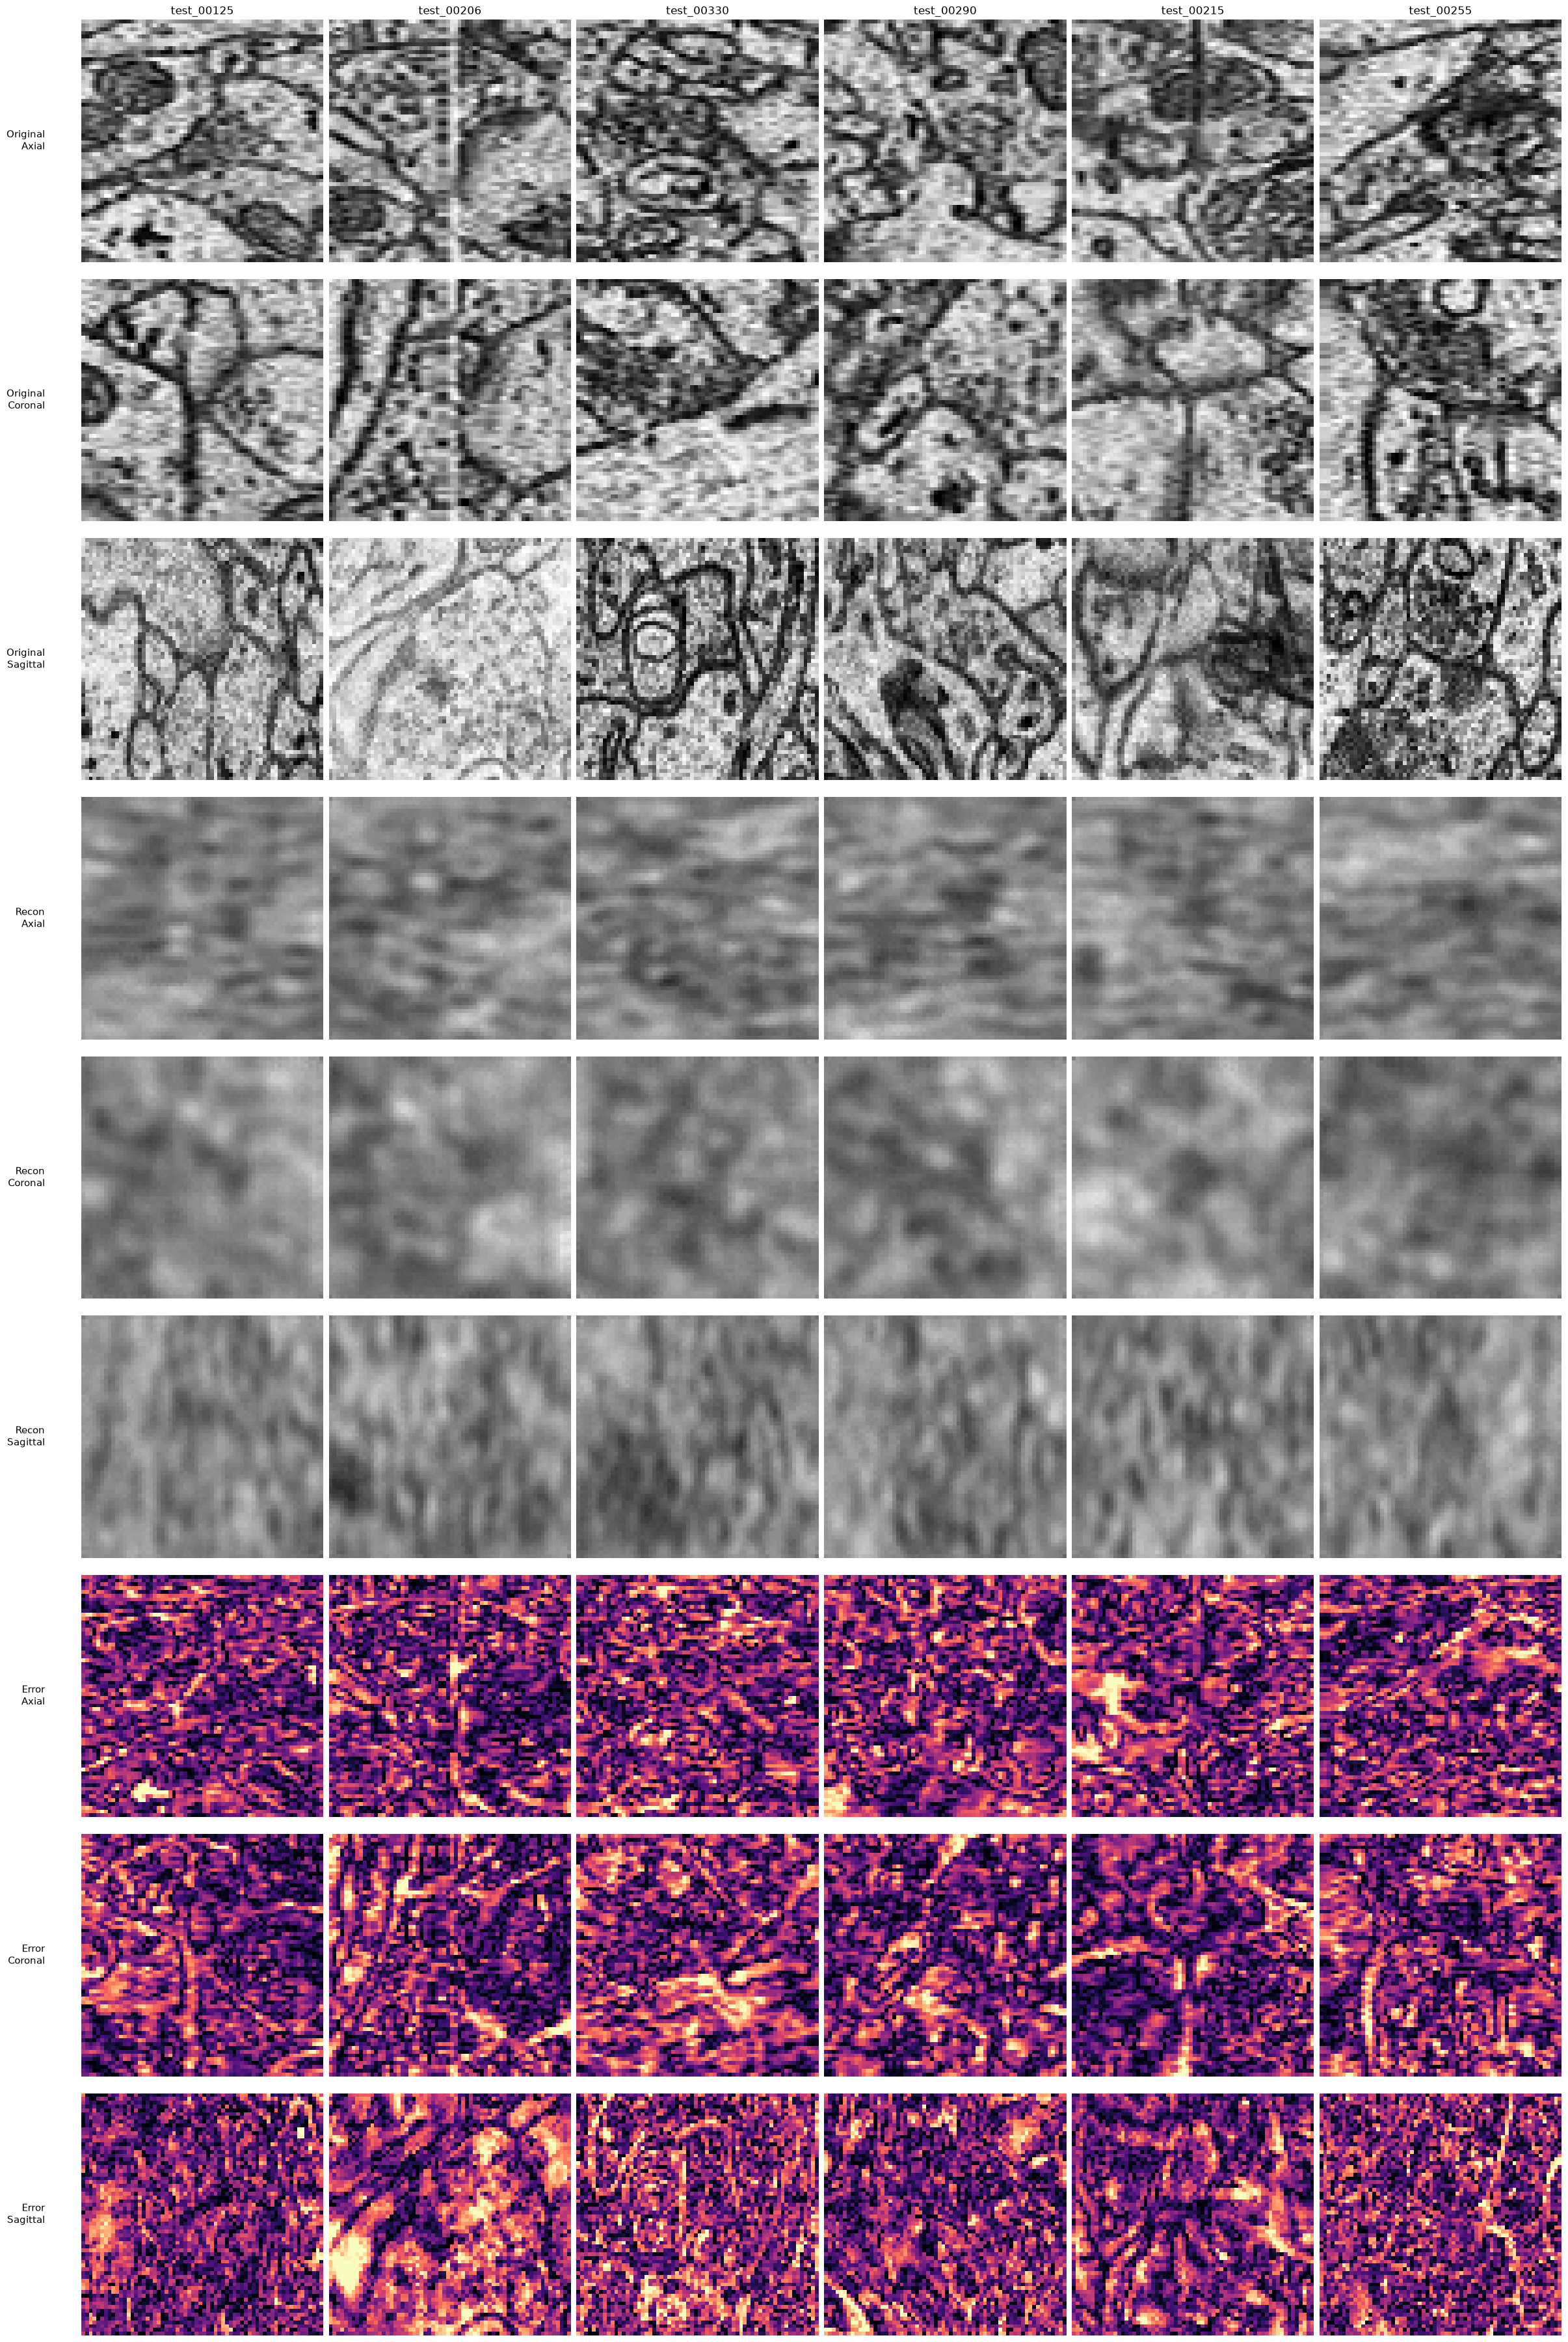

In [9]:
imagix3d_loaded.visualizer.show_image_recon_grid(
    result=imagix3d_loaded.result, 
    n_samples=6
)

**Comparing reconstructions to originals, wrt the best, median and worst examples**

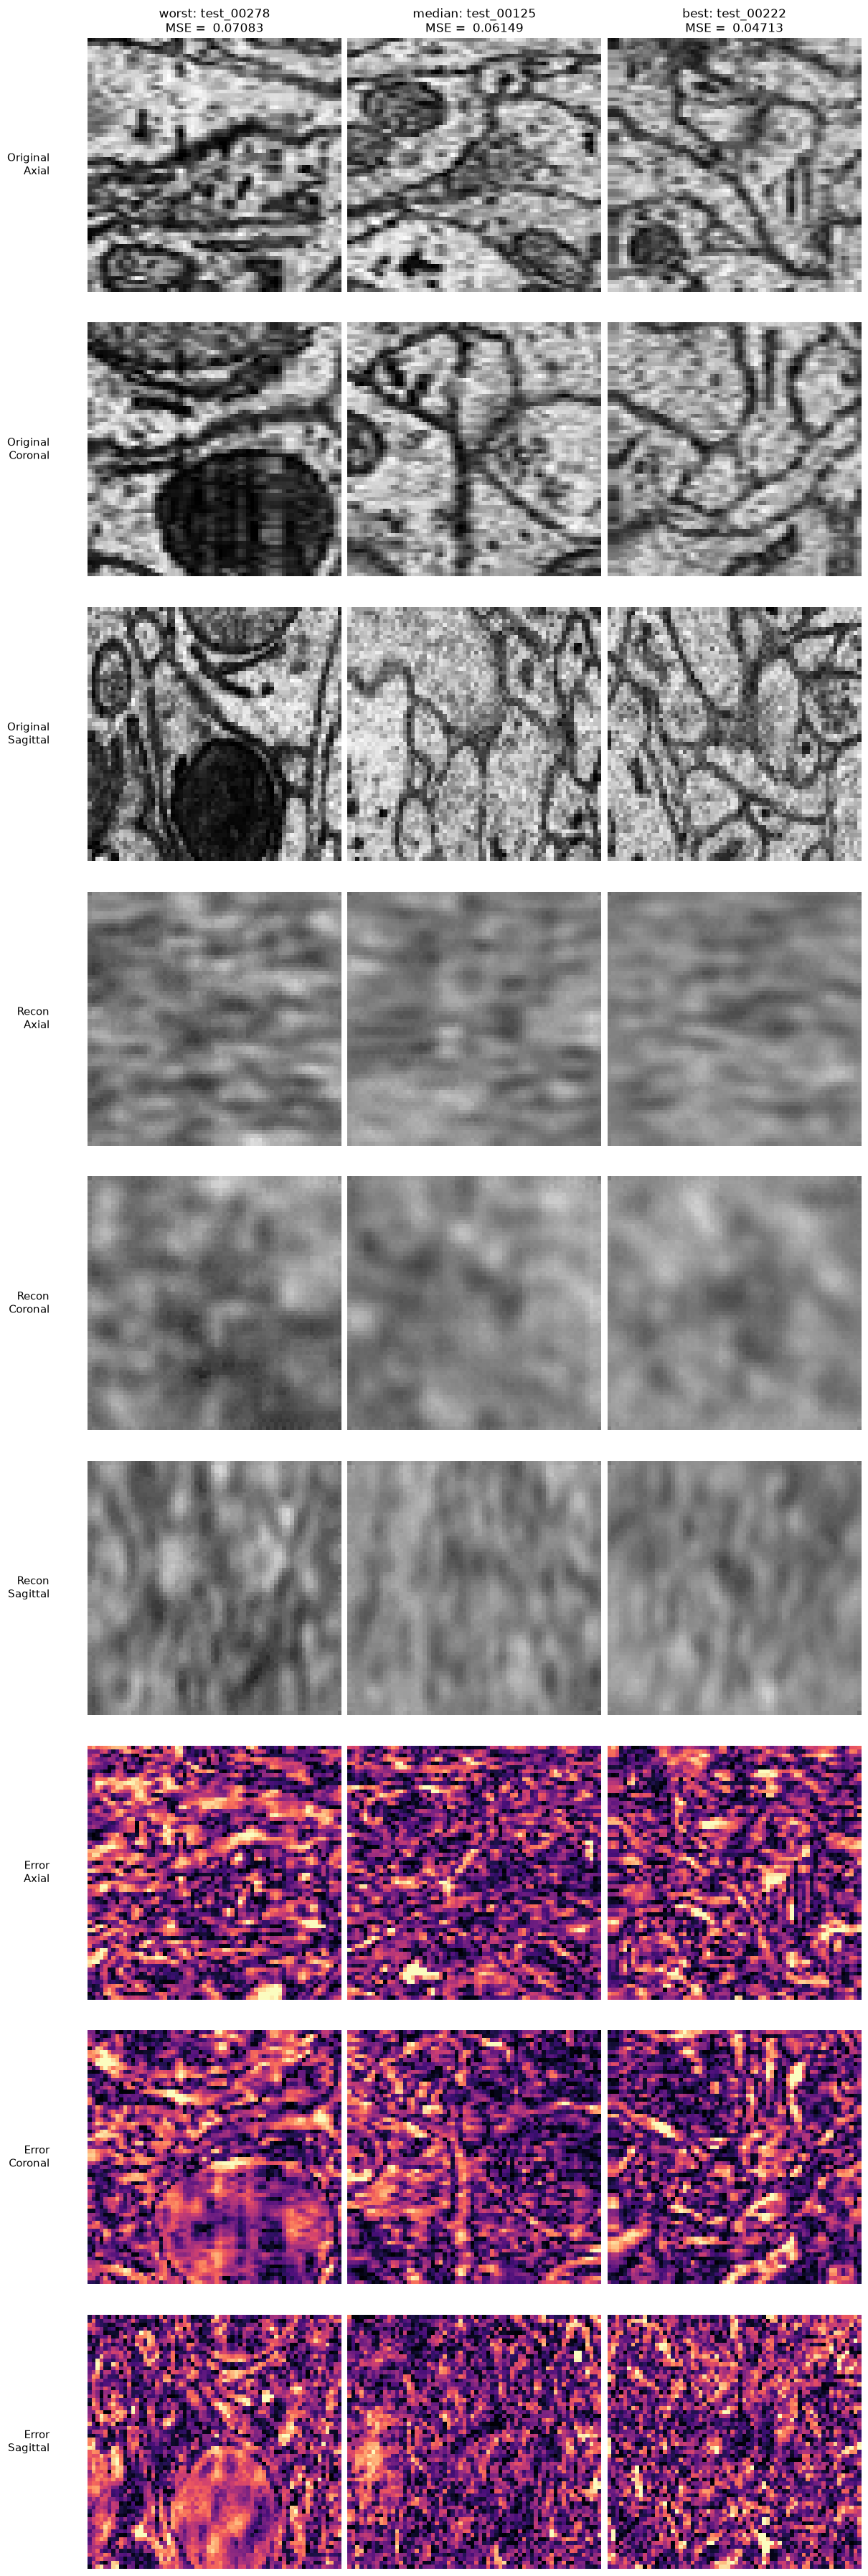

In [10]:
imagix3d_loaded.visualizer.show_image_recon_grid(
    result=imagix3d_loaded.result,
    selection="bmw",
    metric="mse",
)

### Visualize Losses and Latent Spaces

Creating plots ...


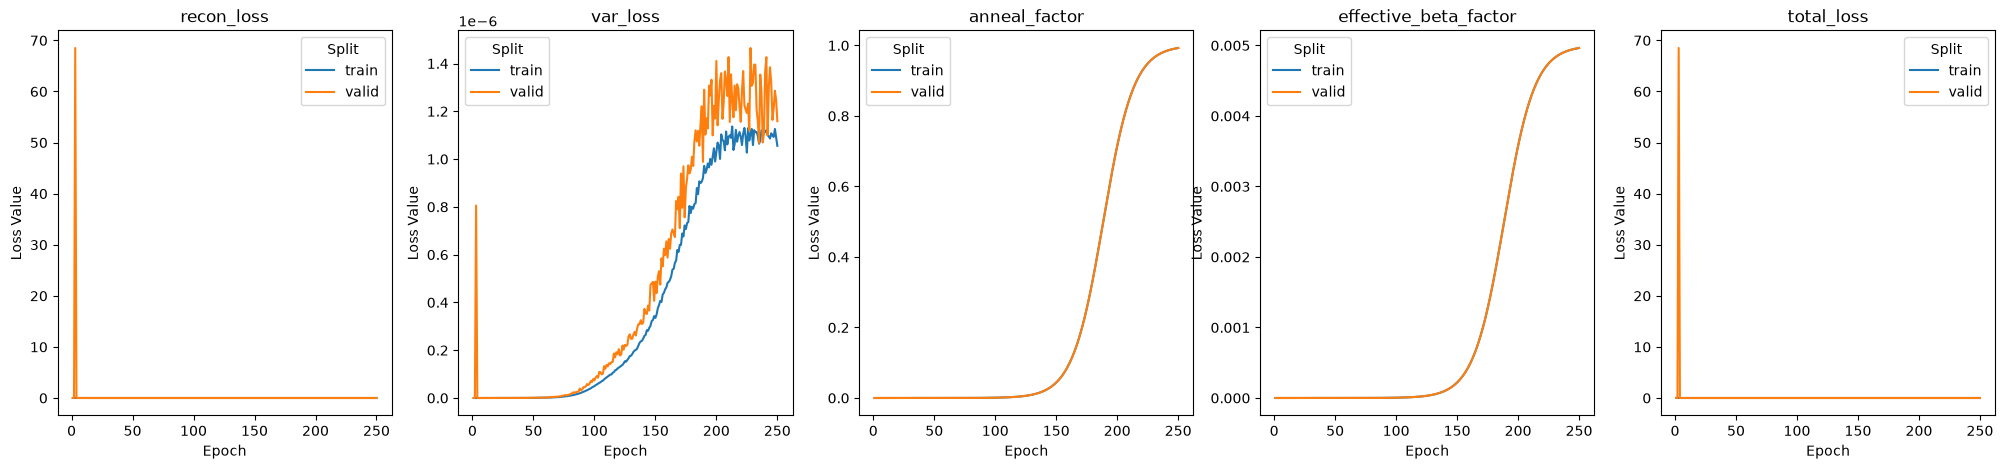

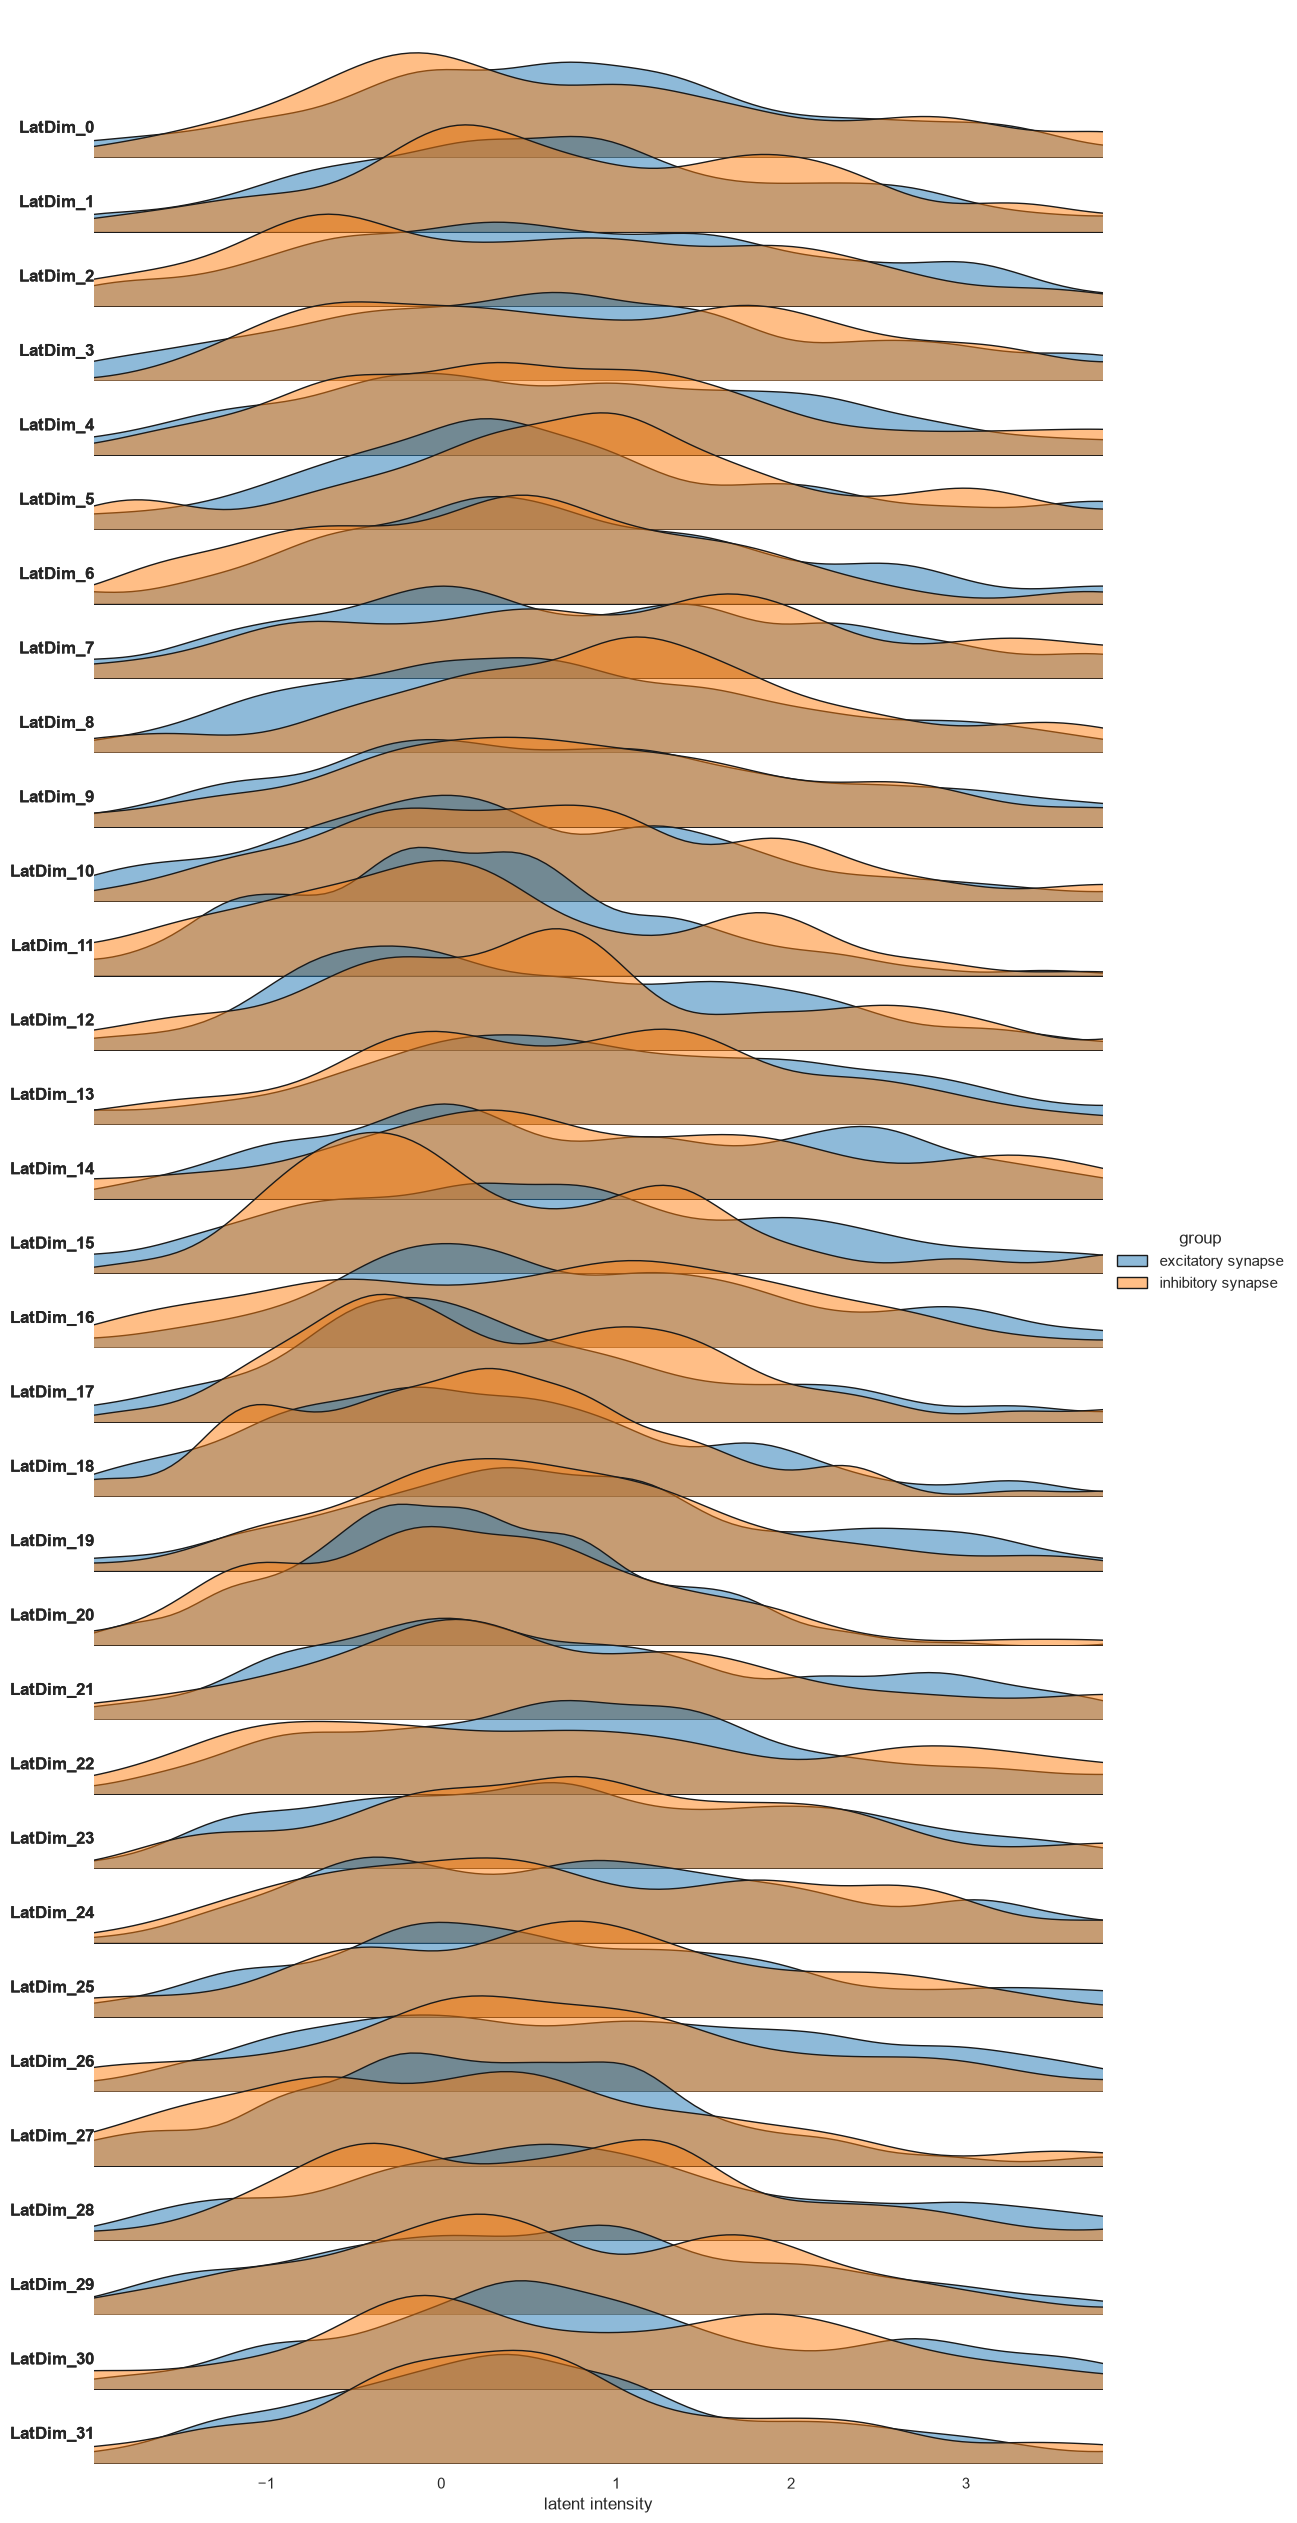

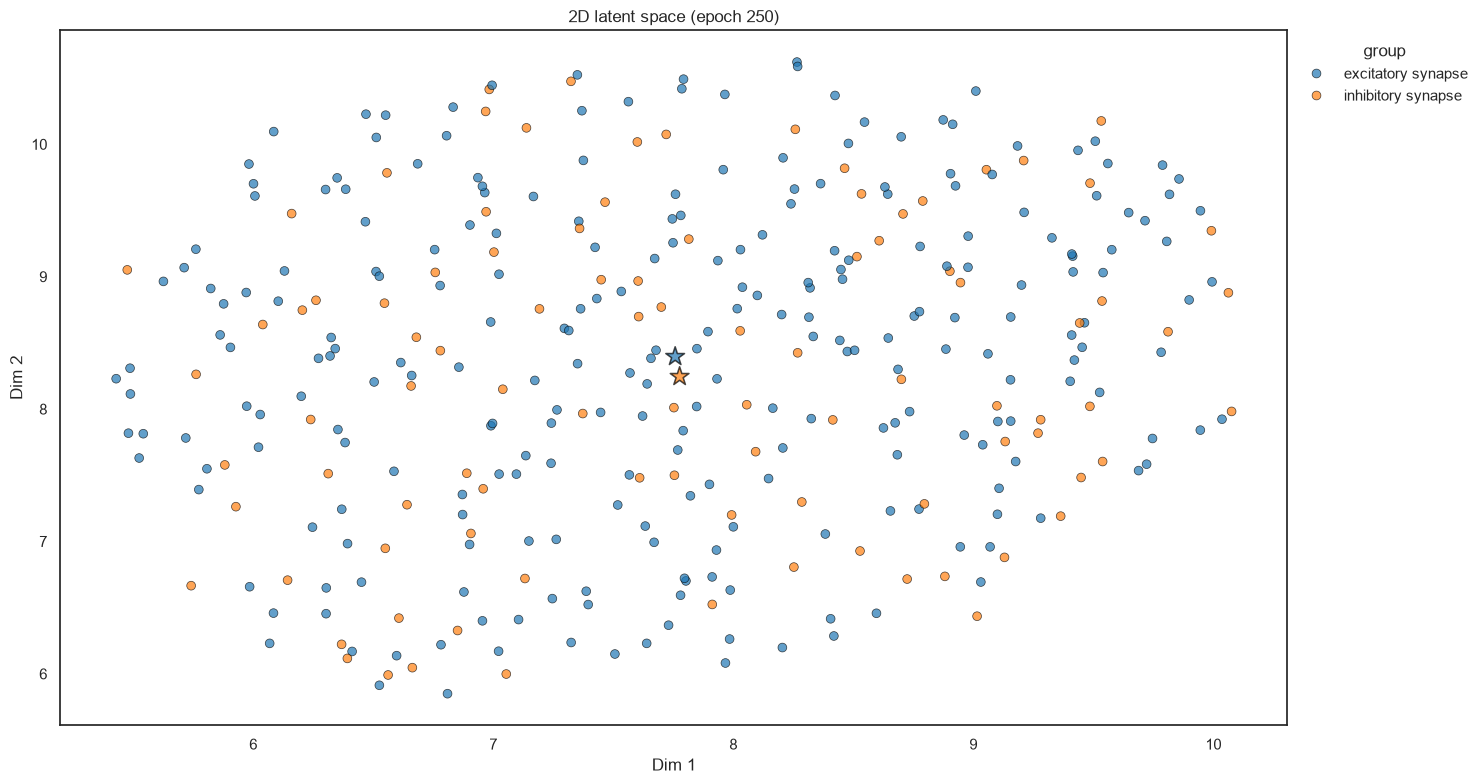

In [11]:
imagix3d_loaded.show_result(
    params=["group"]
)

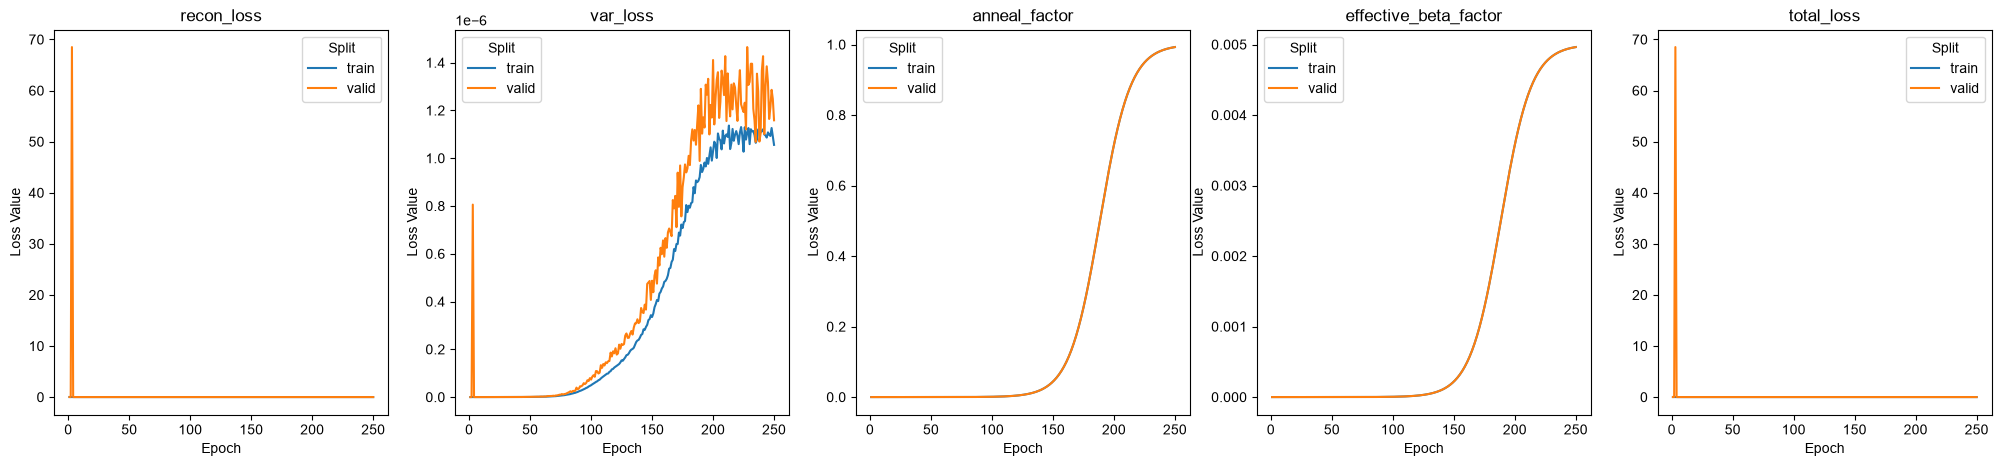

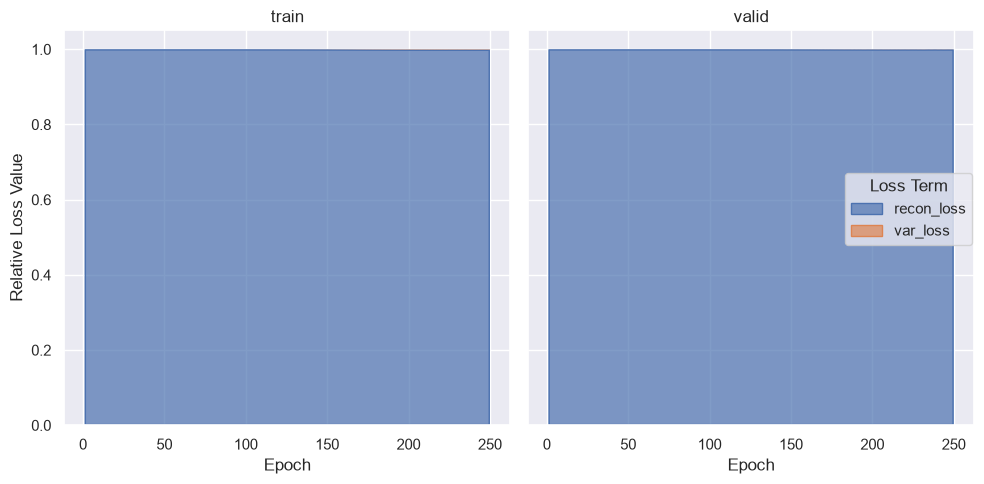

In [12]:
fig_loss_abs = imagix3d_loaded.visualizer.show_loss(plot_type="absolute") # Displays all loss components and factors over epochs
fig_loss_rel = imagix3d_loaded.visualizer.show_loss(plot_type="relative") # Displays contribution of loss components to total loss over epochs

In [13]:
import inspect
import pandas as pd

methods = []

for name, obj in inspect.getmembers(imagix3d_loaded.visualizer, predicate=inspect.ismethod):
    if name.startswith("_"):
        continue

    try:
        source_file = inspect.getfile(obj)
    except TypeError:
        source_file = None

    try:
        signature = str(inspect.signature(obj))
    except ValueError:
        signature = ""

    doc = inspect.getdoc(obj)
    first_doc_line = doc.split("\n")[0] if doc else ""

    methods.append({
        "method": name,
        "signature": signature,
        "defined_in": source_file,
        "doc": first_doc_line,
    })

method_table = pd.DataFrame(methods)
display(method_table)

,method,signature,defined_in,doc
0,save_plots,"(path: str, which: Union[str, list] = 'all', f...",C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,Save specified plots to the given path in the ...
1,show_evaluation,"(param: str, metric: str, ml_alg: Optional[str...",C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,Displays the evaluation plot for a specific cl...
2,show_image_recon_grid,"(result: autoencodix.utils._result.Result, n_s...",C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,"Plot original, reconstructed, and absolute-err..."
3,show_latent_activity,"(result: autoencodix.utils._result.Result, fin...",C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,Visualize latent-dimension activity statistics...
4,show_latent_corr,"(result: autoencodix.utils._result.Result, sho...",C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,
5,show_latent_space,"(result: autoencodix.utils._result.Result, plo...",C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,Visualizes the latent space of the given resul...
6,show_loss,(plot_type: str = 'absolute') -> None,C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,Display the loss plot.
7,show_weights,() -> None,C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,Display the model weights plot if it exists in...
8,visualize,"(result: autoencodix.utils._result.Result, con...",C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Sc...,


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

result = imagix3d_loaded.result
vis = imagix3d_loaded.visualizer

stored_epochs = sorted(
    e for e in result.latentspaces._data.keys()
    if e != -1
)

rows = []

for epoch in stored_epochs:
    for split in ["train", "valid"]:
        latent_df = result.get_latent_df(epoch=epoch, split=split)

        if latent_df.empty:
            continue

        tc = vis._total_correlation(latent_df)
        cov = vis._coverage_calc(latent_df)

        rows.append({
            "epoch": epoch + 1,   # display as human-counted epoch
            "split": split,
            "total_correlation": tc,
            "coverage": cov,
        })

df_metrics = pd.DataFrame(rows)

display(df_metrics.head())
display(df_metrics.tail())
print(df_metrics.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(
    data=df_metrics,
    x="epoch",
    y="total_correlation",
    hue="split",
    ax=axes[0],
)
axes[0].set_title("Total correlation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Total correlation")

sns.lineplot(
    data=df_metrics,
    x="epoch",
    y="coverage",
    hue="split",
    ax=axes[1],
)
axes[1].set_title("Coverage")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Coverage")

plt.tight_layout()
plt.show()

In [ ]:
for key in imagix3d_loaded.visualizer.plots.keys():
    print(key)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


res = imagix3d_loaded.result
vis = imagix3d_loaded.visualizer


def safe_total_correlation(latent_df, eps=1e-6):
    """
    Robust version of AUTOENCODIX total correlation.
    Keeps only finite, non-constant numeric dimensions and regularizes covariance.
    """
    X = latent_df.select_dtypes(include=[np.number]).copy()
    X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

    # remove collapsed / constant latent dimensions
    X = X.loc[:, X.var(axis=0) > eps]

    if X.shape[0] < 3 or X.shape[1] < 2:
        return np.nan

    C = np.cov(X.to_numpy(), rowvar=False)
    C = C + eps * np.eye(C.shape[0])

    diag = np.diag(C)
    sign, logdet = np.linalg.slogdet(C)

    if sign <= 0 or np.any(diag <= 0):
        return np.nan

    tc = 0.5 * (np.sum(np.log(diag)) - logdet)
    return float(tc)


def coverage_after_pca(latent_df, n_components=2, bins=None):
    """
    Coverage after PCA reduction.
    This is not the original 64D coverage; it is reduced-space coverage.
    """
    X = latent_df.select_dtypes(include=[np.number]).copy()
    X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1)

    # remove collapsed dimensions
    X = X.loc[:, X.var(axis=0) > 1e-12]

    if X.shape[0] < 3 or X.shape[1] < 1:
        return np.nan

    k = min(n_components, X.shape[1], X.shape[0] - 1)

    X_scaled = StandardScaler().fit_transform(X)
    X_red = PCA(n_components=k, random_state=0).fit_transform(X_scaled)

    n_samples, d = X_red.shape

    if bins is None:
        bins = int(np.floor(n_samples ** (1 / d)))
        bins = max(2, bins)

    # Keep grid size from exploding
    bins = min(bins, 20)

    if bins < 2:
        return np.nan

    binned_cols = []

    for j in range(d):
        if np.nanstd(X_red[:, j]) < 1e-12:
            return np.nan

        binned = pd.cut(
            X_red[:, j],
            bins=bins,
            labels=False,
            include_lowest=True,
        )

        binned_cols.append(binned)

    occupied_cells = set(zip(*binned_cols))
    possible_cells = bins ** d

    return len(occupied_cells) / possible_cells


rows = []

stored_epochs = sorted(
    e for e in res.latentspaces._data.keys()
    if e != -1
)

print("Stored train/valid latent epochs:", stored_epochs)

for epoch in stored_epochs:
    for split in ["train", "valid"]:

        try:
            latent_df = res.get_latent_df(epoch=epoch, split=split)
        except Exception as exc:
            print(f"Skipping epoch={epoch}, split={split}: {exc}")
            continue

        if latent_df.empty:
            print(f"Skipping epoch={epoch}, split={split}: empty latent DataFrame")
            continue

        n_samples, n_dims = latent_df.shape
        original_bins_per_dim = int(np.floor(n_samples ** (1 / n_dims)))

        rows.append({
            "epoch": epoch + 1,
            "split": split,
            "n_samples": n_samples,
            "n_dims": n_dims,
            "original_bins_per_dim": original_bins_per_dim,
            "total_correlation_64d": safe_total_correlation(latent_df),
            "coverage_original_64d": np.nan,  # intentionally NaN: not meaningful here
            "coverage_pca2": coverage_after_pca(latent_df, n_components=2),
            "coverage_pca6": coverage_after_pca(latent_df, n_components=6),
        })


df_metrics = pd.DataFrame(rows)

display(df_metrics)

if df_metrics.empty:
    raise RuntimeError(
        "No train/valid latent representations were found. "
        "Check res.latentspaces._data and make sure you are using imagix3d_loaded.result."
    )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(
    data=df_metrics,
    x="epoch",
    y="total_correlation_64d",
    hue="split",
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Total correlation, 64D latent space")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Total correlation")

sns.lineplot(
    data=df_metrics,
    x="epoch",
    y="coverage_pca2",
    hue="split",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Coverage after PCA to 2D")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Coverage")

sns.lineplot(
    data=df_metrics,
    x="epoch",
    y="coverage_pca6",
    hue="split",
    marker="o",
    ax=axes[2],
)
axes[2].set_title("Coverage after PCA to 6D")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Coverage")

plt.tight_layout()
plt.show()

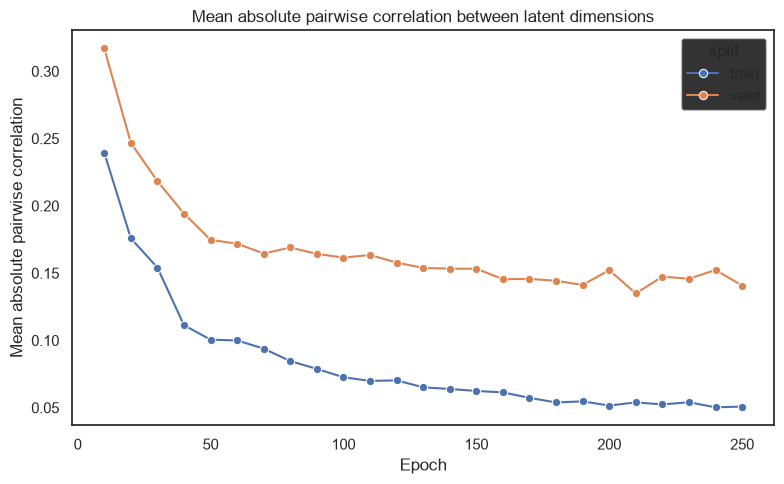

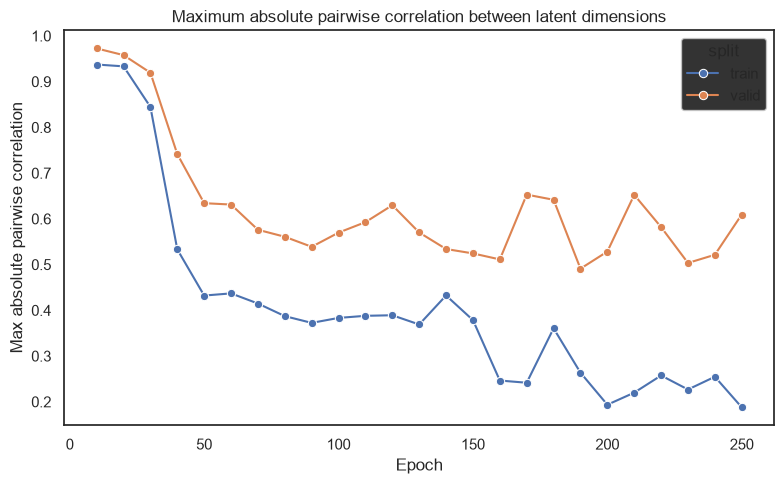

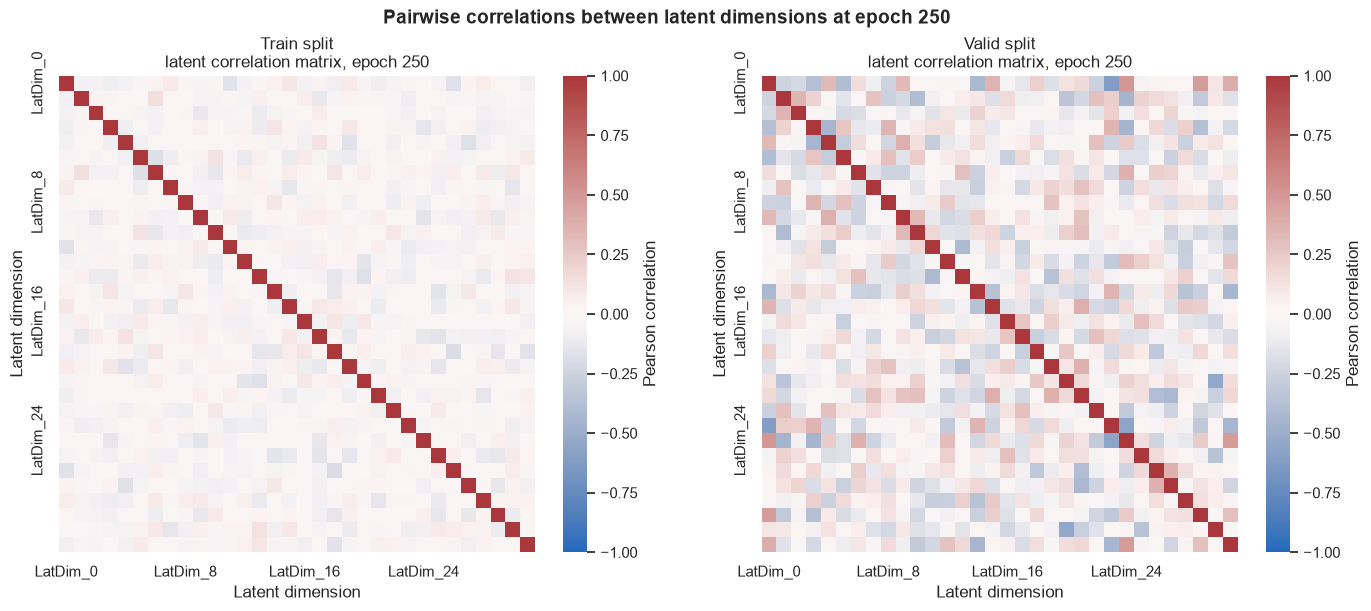

,epoch,split,mean_abs_pairwise_corr,max_abs_pairwise_corr,n_samples,n_latent_dims
0,10,train,0.239424,0.937337,246,32
1,10,valid,0.316978,0.972570,35,32
2,20,train,0.175783,0.933356,246,32
3,20,valid,0.246723,0.957899,35,32
4,30,train,0.154115,0.844630,246,32
5,30,valid,0.218313,0.919434,35,32
6,40,train,0.111253,0.533168,246,32
7,40,valid,0.194245,0.741556,35,32
8,50,train,0.100549,0.432180,246,32
9,50,valid,0.174727,0.634186,35,32


In [14]:
imagix3d_loaded.visualizer.show_latent_corr(
    result=imagix3d_loaded.result,
    show_table=True,
    show_corrmat=True
)

In [15]:
import inspect

display(type(imagix3d_loaded.evaluator))
print(inspect.getfile(type(imagix3d_loaded.evaluator)))
print(inspect.getsource(imagix3d_loaded.evaluate))

autoencodix.evaluate._general_evaluator.GeneralEvaluator

C:\Users\chris\OneDrive\Desktop\FU\Msc_Data_Science\Masterarbeit\autoencodix_package\src\autoencodix\evaluate\_general_evaluator.py
    def evaluate(
        self,
        ml_model_class: ClassifierMixin = linear_model.LogisticRegression(),
        ml_model_regression: RegressorMixin = linear_model.LinearRegression(),
        params: Union[
            list, str
        ] = [],  # Default empty list, to use all parameters use string "all"
        metric_class: str = "roc_auc_ovo",  # Default is 'roc_auc_ovo' via https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names
        metric_regression: str = "r2",  # Default is 'r2'
        reference_methods: list = [],  # Default [], Options are "PCA", "UMAP", "TSNE", "RandomFeature"
        reference_reducer: dict = {},  # Option to provide pre-fitted reducer objects for PCA, UMAP or TSNE, e.g. {"PCA": pca_reducer, "UMAP": umap_reducer, "TSNE": tsne_reducer}
        split_type: Literal[
            "use-split", "CV-

**Inspect latent dimension "activity"**

In [16]:
from autoencodix.evaluate._imagix3d_evaluator import Imagix3DEvaluator

imagix3d_loaded.evaluator = Imagix3DEvaluator()

,epoch,epoch_display,split,is_test_prediction,threshold,n_samples,n_latent_dims,n_active_units,fraction_active,mean_activity,median_activity,max_activity,sum_kl,mean_kl
0,-1,250,test,True,0.5,71,32,26,0.81250,1.064643,1.082284,1.984187,27.595247,0.862351
1,9,10,train,False,0.5,246,32,16,0.50000,4.262106,0.669192,21.734099,292.926330,9.153948
2,9,10,valid,False,0.5,35,32,17,0.53125,6.117276,0.709713,34.644092,449.509628,14.047176
3,19,20,train,False,0.5,246,32,18,0.56250,6.425815,3.898326,29.613881,255.744297,7.992009
4,19,20,valid,False,0.5,35,32,18,0.56250,4.692253,2.214337,29.928545,170.356968,5.323655
5,29,30,train,False,0.5,246,32,21,0.65625,6.242697,5.009538,27.120280,510.851092,15.964097
6,29,30,valid,False,0.5,35,32,21,0.65625,7.221847,4.245841,34.427231,645.616211,20.175507
7,39,40,train,False,0.5,246,32,21,0.65625,11.487819,14.209831,26.414430,847.482490,26.483828
8,39,40,valid,False,0.5,35,32,23,0.71875,11.175805,11.070875,30.179338,897.410992,28.044093
9,49,50,train,False,0.5,246,32,24,0.75000,20.487922,26.831647,41.063878,1166.218304,36.444322


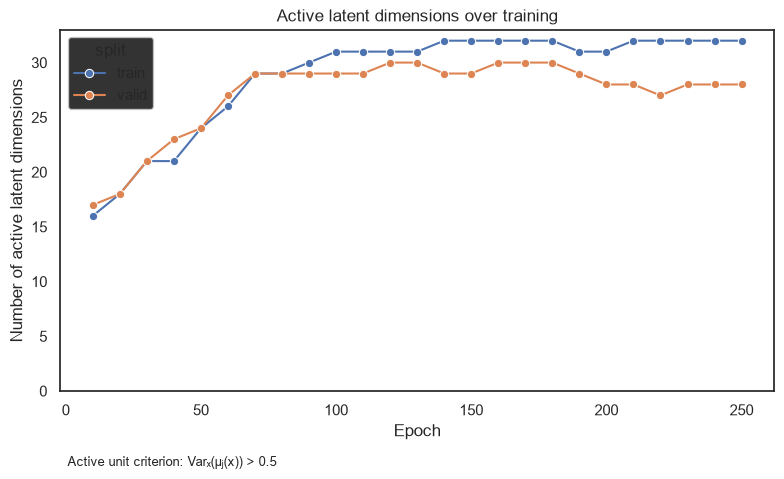

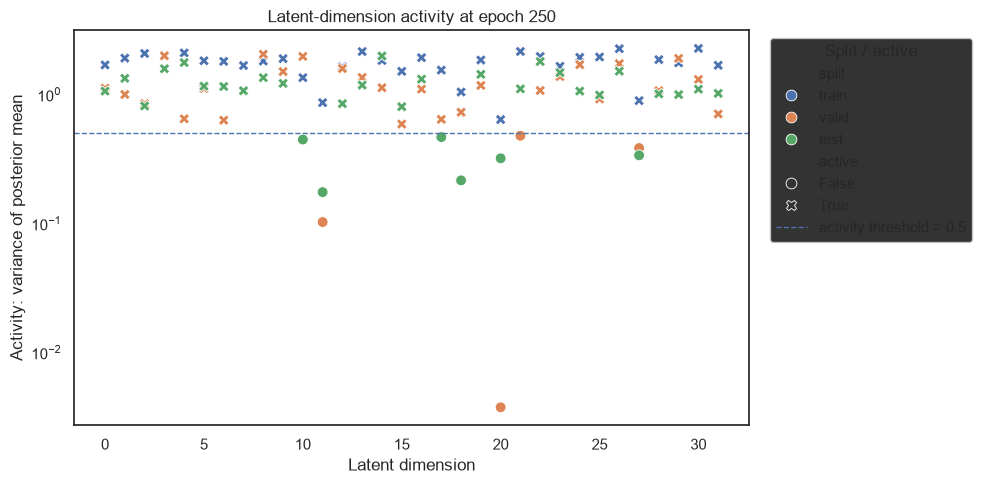

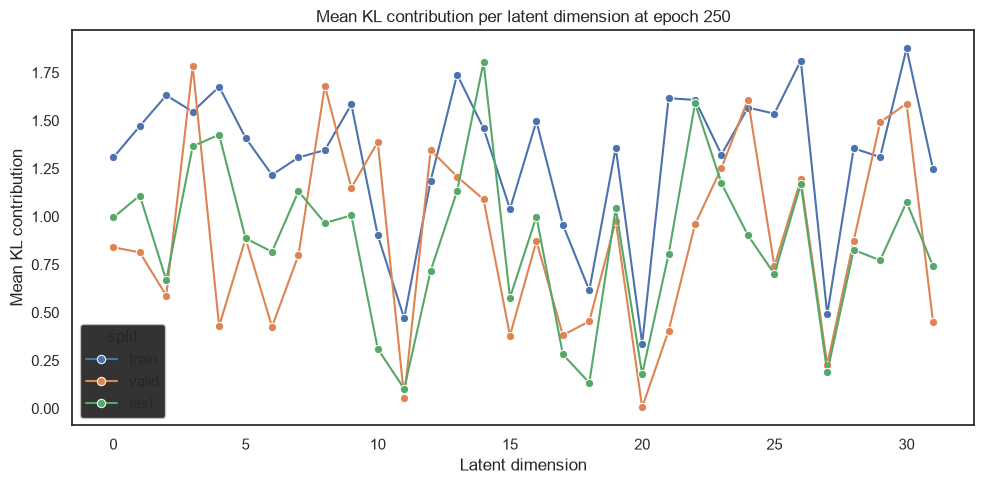

In [20]:
imagix3d_loaded.result = imagix3d_loaded.evaluator.compute_latent_activity(
    result=imagix3d_loaded.result,
    threshold=0.01,
    splits=("train", "valid"),
    include_test=True,
)

imagix3d_loaded.visualizer.show_latent_activity(
    result=imagix3d_loaded.result,
    show_table=True,
    show_dim_table=False,
)

**Check what is going on with below threshold values**

In [ ]:
dim_df = imagix3d_loaded.result.sub_results["imagix3d_latent_activity_by_dim"]

final_epoch = dim_df.loc[~dim_df["is_test_prediction"], "epoch"].max()
final_rows = dim_df.loc[(dim_df["epoch"] == final_epoch) | (dim_df["is_test_prediction"])].copy()

threshold = final_rows["threshold"].iloc[0]

check = final_rows.groupby("split").agg(
    n_dims=("latent_dim", "count"),
    n_active=("active", "sum"),
    n_inactive=("active", lambda x: (~x).sum()),
    n_zero_activity=("activity", lambda x: (x <= 0).sum()),
    n_below_or_equal_threshold=("activity", lambda x: (x <= threshold).sum()),
)

display(check)


In [ ]:
dim_df = imagix3d_loaded.result.sub_results["imagix3d_latent_activity_by_dim"]

final_epoch = dim_df.loc[~dim_df["is_test_prediction"], "epoch"].max()

final_train = dim_df.loc[
    (dim_df["epoch"] == final_epoch)
    & (dim_df["split"] == "train")
].copy()

display(
    final_train[
        ["latent_dim", "activity", "active", "mean_mu", "std_mu", "mean_logvar", "mean_kl"]
    ].sort_values("mean_kl", ascending=False).head(15)
)